In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline  # pipeline của imblearn hỗ trợ SMOTE
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, f1_score
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import numpy as np




In [2]:
df_encoded = pd.read_csv("superstore_encoded.csv")
df_encoded.head()

,Education,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Customer_Tenure,Age,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,2,84835.0,0,0,0,189,104,379,111,189,...,173,55,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2,57091.0,0,0,0,464,5,64,7,0,...,174,64,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,2,67267.0,0,1,0,134,11,59,15,2,...,207,67,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,2,32474.0,1,1,0,10,0,1,0,0,...,31,58,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,2,21474.0,1,0,0,6,16,24,11,0,...,124,36,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [3]:
df_encoded.info()
df_encoded.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2031 entries, 0 to 2030
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Education                2031 non-null   int64  
 1   Income                   2031 non-null   float64
 2   Kidhome                  2031 non-null   int64  
 3   Teenhome                 2031 non-null   int64  
 4   Recency                  2031 non-null   int64  
 5   MntWines                 2031 non-null   int64  
 6   MntFruits                2031 non-null   int64  
 7   MntMeatProducts          2031 non-null   int64  
 8   MntFishProducts          2031 non-null   int64  
 9   MntSweetProducts         2031 non-null   int64  
 10  MntGoldProds             2031 non-null   int64  
 11  NumDealsPurchases        2031 non-null   int64  
 12  NumWebPurchases          2031 non-null   int64  
 13  NumCatalogPurchases      2031 non-null   int64  
 14  NumStorePurchases       

,Education,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,Customer_Tenure,Age,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
count,2031.000000,2031.000000,2031.000000,2031.000000,2031.000000,2031.000000,2031.000000,2031.000000,2031.000000,2031.000000,...,2031.000000,2031.000000,2031.000000,2031.000000,2031.000000,2031.000000,2031.000000,2031.000000,2031.000000,2031.000000
mean,2.464303,52346.328902,0.443131,0.508616,48.838996,305.248646,26.257509,167.728213,37.446578,27.147710,...,511.340719,56.091581,0.000985,0.001477,0.105859,0.387986,0.215657,0.252585,0.034466,0.000985
std,1.005689,25533.464407,0.535987,0.546191,28.976637,337.298807,39.709576,226.732978,54.804255,41.509472,...,232.838795,11.663994,0.031373,0.038414,0.307733,0.487411,0.411379,0.434602,0.182467,0.031373
min,0.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,29.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,35482.000000,0.000000,0.000000,24.000000,23.000000,2.000000,16.000000,3.000000,1.000000,...,337.000000,48.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,51529.000000,0.000000,0.000000,49.000000,176.000000,8.000000,68.000000,12.000000,8.000000,...,512.000000,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.000000,68474.500000,1.000000,1.000000,74.000000,505.000000,33.000000,230.000000,50.000000,33.500000,...,685.000000,66.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
max,4.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,...,1063.000000,85.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [4]:
X = df_encoded.drop(columns=['Response'])
y = df_encoded['Response']

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22204\1620952239.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Set1', len(classes))


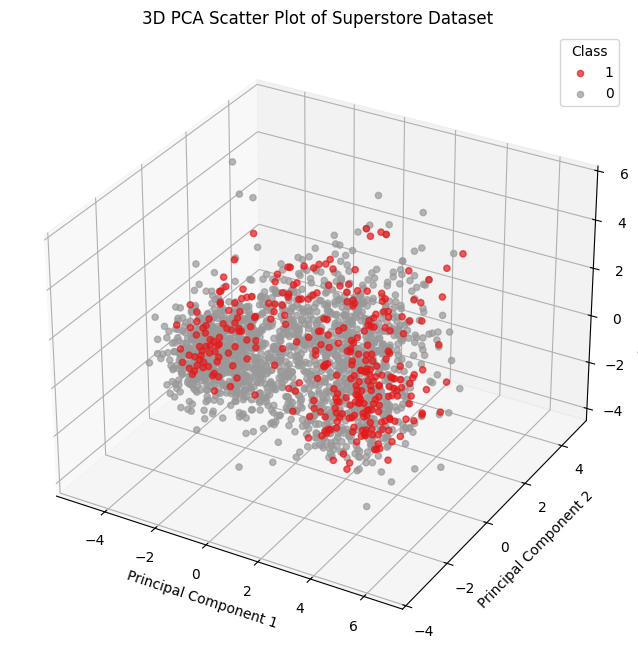

In [8]:

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Giảm chiều xuống 3 thành phần chính
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Tạo plot 3D
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# Tô màu theo lớp
classes = y.unique()
colors = plt.cm.get_cmap('Set1', len(classes))

for i, cls in enumerate(classes):
    idx = y == cls
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1], X_pca[idx, 2],
               label=str(cls), alpha=0.7, color=colors(i))

ax.set_title('3D PCA Scatter Plot of Superstore Dataset')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.legend(title='Class')
plt.show()



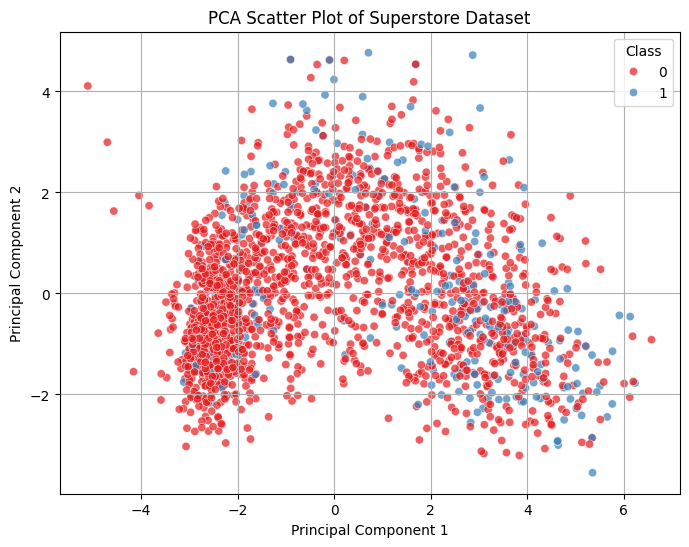

In [9]:

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Giảm chiều PCA xuống 2 thành phần
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Tạo DataFrame để vẽ
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Class'] = y.values

# Vẽ scatter plot với seaborn
plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', hue='Class', data=pca_df, palette='Set1', alpha=0.7)
plt.title('PCA Scatter Plot of Superstore Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Class')
plt.grid(True)

plt.savefig("scatter_plt_dt1", dpi = 300)

plt.show()


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22204\2723206101.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Set1', len(classes))


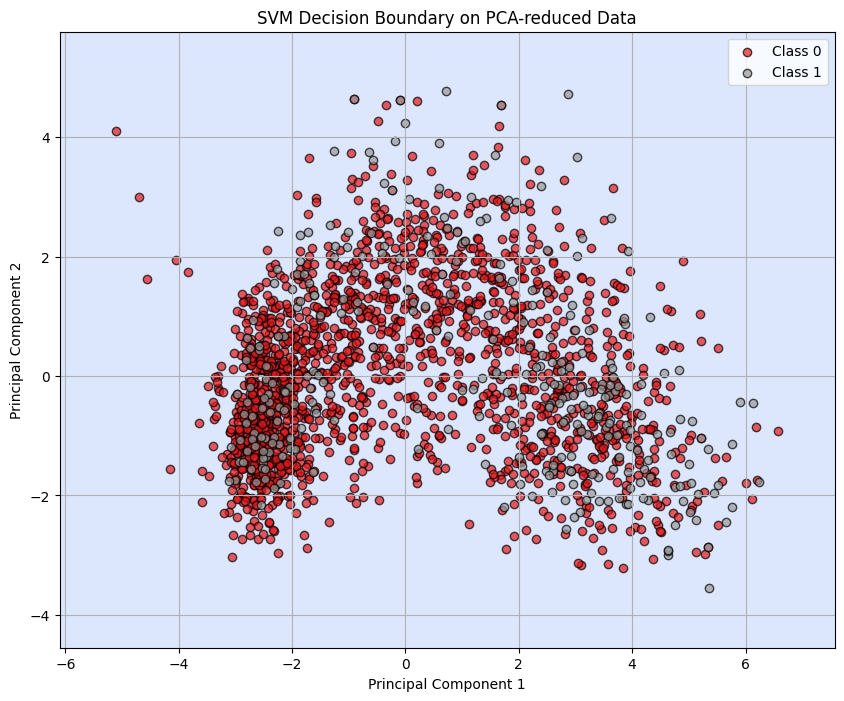

In [17]:

# Chuẩn hóa dữ liệu với  StandardScaler 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Giảm chiều PCA về 2 thành phần
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Huấn luyện mô hình SVM trên dữ liệu PCA 2D với kernel RBF
svm = SVC(kernel='rbf', gamma='scale', decision_function_shape='ovr', random_state=42)
svm.fit(X_pca, y)

# Tạo lưới điểm để dự đoán vùng quyết định
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# Dự đoán lớp cho từng điểm trên lưới
Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Vẽ vùng quyết định (decision boundary)
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

# Vẽ scatter plot dữ liệu thực tế, xử lý đa lớp nếu có
classes = np.unique(y)
colors = plt.cm.get_cmap('Set1', len(classes))

for i, cls in enumerate(classes):
    plt.scatter(X_pca[y == cls, 0], X_pca[y== cls, 1], 
                color=colors(i), label=f'Class {cls}', edgecolor='k', alpha=0.7)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('SVM Decision Boundary on PCA-reduced Data')
plt.legend()
plt.grid(True)
plt.show()



In [10]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Label distribution in train:")
print(y_train.value_counts(normalize=True))
print("Label distribution in test:")
print(y_test.value_counts(normalize=True))

Train size: (1421, 27)
Test size: (610, 27)
Label distribution in train:
Response
0    0.846587
1    0.153413
Name: proportion, dtype: float64
Label distribution in test:
Response
0    0.845902
1    0.154098
Name: proportion, dtype: float64


In [11]:

# Tạo pipeline gồm chuẩn hóa, oversampling, và SVM
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),  # giữ 95% phương sai
    ('smote', SMOTE(random_state=42)),
    ('svm', SVC(class_weight='balanced', kernel='rbf', random_state=42))
])

# Huấn luyện trên tập train
pipeline.fit(X_train, y_train)

# Dự đoán trên test
y_pred = pipeline.predict(X_test)

# Đánh giá kết quả
print("Classification Report with PCA + SMOTE:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix with PCA + SMOTE:")
print(confusion_matrix(y_test, y_pred))

Classification Report with PCA + SMOTE:
              precision    recall  f1-score   support

           0       0.93      0.85      0.89       516
           1       0.46      0.67      0.54        94

    accuracy                           0.83       610
   macro avg       0.70      0.76      0.72       610
weighted avg       0.86      0.83      0.84       610

Confusion Matrix with PCA + SMOTE:
[[441  75]
 [ 31  63]]


In [13]:
# Tạo pipeline gồm chuẩn hóa, oversampling, và SVM
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),  # giữ 95% phương sai
    ('smote', SMOTE(random_state=42)),
    ('svm', SVC(class_weight='balanced', kernel='rbf', random_state=42))
])

# Lưới tham số để tìm kiếm
param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': [0.001, 0.01, 0.1, 1]
}

# Sử dụng F1 macro để đánh giá (cân bằng cả precision và recall)
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring=make_scorer(f1_score, average='macro'),
    cv=5,
    n_jobs=-1
)

# Huấn luyện
grid_search.fit(X_train, y_train)

# Kết quả tốt nhất
print("Best Parameters:", grid_search.best_params_)
print("Best Macro F1-score:", grid_search.best_score_)

# Đánh giá trên tập test
y_pred = grid_search.best_estimator_.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Best Parameters: {'svm__C': 100, 'svm__gamma': 0.001}
Best Macro F1-score: 0.6838269025599912
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.83      0.88       516
           1       0.45      0.78      0.57        94

    accuracy                           0.82       610
   macro avg       0.70      0.80      0.73       610
weighted avg       0.88      0.82      0.84       610

Confusion Matrix:
[[426  90]
 [ 21  73]]
